# 텍스트 분석(NLP, TA)


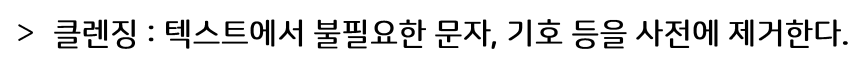


In [3]:
# stevejobs.txt 파일 열어서 한 줄로 합치기

with open("./data/stevejobs.txt", "r", encoding="utf8") as f:
    rows = f.readlines()
    lines = [row for row in rows]
text = " ".join(lines)
print(text[:200])

This is the text of the Commencement address by Steve Jobs, CEO of Apple Computer and of Pixar Animation Studios, delivered on June 12, 2005.
 
  
 I am honored to be with you today at your commenceme


In [4]:
# Regular Expression 활용하여 알파벳 소문자로 통일

import re

compile = re.compile("[^ a-zA-Z0-9\\.]+")
text = compile.sub("", text).lower()
print(text[:200])

this is the text of the commencement address by steve jobs ceo of apple computer and of pixar animation studios delivered on june 12 2005.    i am honored to be with you today at your commencement fro


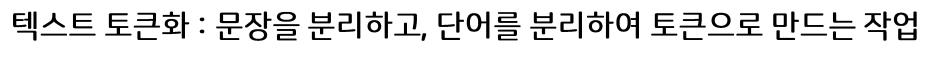


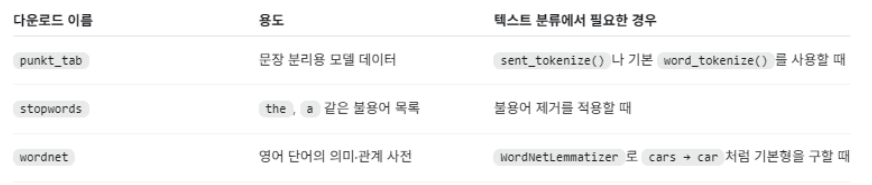


#### nltk : 파이썬에서 자연어 처리(NLP)를 할 때 사용하는 라이브러리


In [7]:
# 문장 토큰화 (Tokenizing)
import nltk

nltk.download("punkt_tab")
sentences = nltk.sent_tokenize(text=text)
print(sentences[:3])

['this is the text of the commencement address by steve jobs ceo of apple computer and of pixar animation studios delivered on june 12 2005.    i am honored to be with you today at your commencement from one of the finest universities in the world.', 'i never graduated from college.', 'truth be told this is the closest ive ever gotten to a college graduation.']


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rlawjdgns213\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [14]:
# 단어 토큰화
word_token = []
for sentence in sentences:
    words = nltk.word_tokenize(sentence)
    word_token.extend(words)
print(word_token[:10])

['this', 'is', 'the', 'text', 'of', 'the', 'commencement', 'address', 'by', 'steve']


#### nltk.sent_tokenize() : 텍스트를 문장별로 나누기


In [15]:
nltk.sent_tokenize(
    text="나는 배가 고프다. 곧 있으면 점심 시간이다. 오늘 점심은 뭘까? 기대되네."
)

['나는 배가 고프다.', '곧 있으면 점심 시간이다.', '오늘 점심은 뭘까?', '기대되네.']

#### nltk.word_tokenize() : 문장을 세부 요소로 나누기


In [16]:
nltk.sent_tokenize(
    text="I'm really hungry that I think I can eat everything at once. What's the lunch today? Can't wait for it."
)

["I'm really hungry that I think I can eat everything at once.",
 "What's the lunch today?",
 "Can't wait for it."]

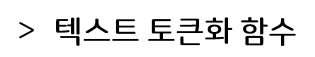


In [18]:
def tokenize_text(text):
    sentences = nltk.sent_tokenize(text)
    word_tokens = [nltk.word_tokenize(sentence) or sentense in sentences]
    return word_tokens


word_tokens = tokenize_text(text)
print(word_tokens[:2])

[['thank', 'you', 'all', 'very', 'much', '.']]


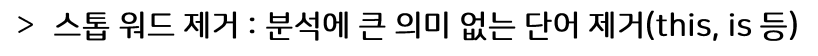


- 불용어(Stopword) : 텍스트에서 자주 등장하지만 분석이나 검색에 큰 의미를 주지 않아 [자연어 처리] 전처리 과정에서 제거하는 단어들


In [ ]:
nltk.download("stopwords")
stopwords = nltk.corpus.stopwords.words("english")
print("영어 stop words 개수: ", len(stopwords))
print(stopwords[:10])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rlawjdgns213\AppData\Roaming\nltk_data...


영어 stop words 개수:  198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


[nltk_data]   Unzipping corpora\stopwords.zip.


In [20]:
filtered_words = []
for word in word_token:
    if word not in stopwords:
        filtered_words.append(word)
print(filtered_words[:10])

['text', 'commencement', 'address', 'steve', 'jobs', 'ceo', 'apple', 'computer', 'pixar', 'animation']


#### <단어의 원형을 찾는 기법>

- Stemming :
- Lemmatization :


In [22]:
# 어근을 찾아주는 기능인듯?
from nltk.stem import LancasterStemmer

#
stemmer = LancasterStemmer()

print(stemmer.stem("working"))
print(stemmer.stem("works"))
print(stemmer.stem("worked"))


print(stemmer.stem("cars"))

work
work
work
car


In [ ]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")

lemma = WordNetLemmatizer()
print(lemma.lemmatize("amusing", "v"))
print(lemma.lemmatize("amuses", "v"))
print(lemma.lemmatize("amused", "v"))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rlawjdgns213\AppData\Roaming\nltk_data...


amuse
amuse
amuse


In [24]:
filtered_words = []
for word in word_token:
    stemmed_word = stemmer.stem(word)
    if stemmed_word not in stopwords:
        filtered_words.append(stemmed_word)
print(filtered_words[:10])

['thi', 'text', 'com', 'address', 'stev', 'job', 'ceo', 'appl', 'comput', 'pix']


## 텍스트 분류 실습 - 20 뉴스그룹


In [38]:
sentences = [
    "I like machine learning and data science",
    "Machine learning is useful for data analysis is is ",
    "Python is popular for machine learning",
    "I like Python and data analysis and",
    "Data science uses Python and machine learning",
]

In [47]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Count 벡터화
cnt_vect = CountVectorizer()
cnt_vect.fit(sentences)
sent = cnt_vect.transform(sentences)

# TF-IDF 벡터화
tfidf_vect = TfidfVectorizer()
tfidf_vect.fit(sentences)
sent_tf = tfidf_vect.transform(sentences)

In [46]:
sent

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 31 stored elements and shape (5, 13)>

In [48]:
sent_tf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 31 stored elements and shape (5, 13)>

In [41]:
cnt_vect.vocabulary_

{'like': 6,
 'machine': 7,
 'learning': 5,
 'and': 1,
 'data': 2,
 'science': 10,
 'is': 4,
 'useful': 11,
 'for': 3,
 'analysis': 0,
 'python': 9,
 'popular': 8,
 'uses': 12}

In [42]:
cnt_vect.get_feature_names_out()

array(['analysis', 'and', 'data', 'for', 'is', 'learning', 'like',
       'machine', 'popular', 'python', 'science', 'useful', 'uses'],
      dtype=object)

In [49]:
pd.DataFrame(sent.toarray(), columns=cnt_vect.get_feature_names_out())

,analysis,and,data,for,is,learning,like,machine,popular,python,science,useful,uses
0,0,1,1,0,0,1,1,1,0,0,1,0,0
1,1,0,1,1,3,1,0,1,0,0,0,1,0
2,0,0,0,1,1,1,0,1,1,1,0,0,0
3,1,2,1,0,0,0,1,0,0,1,0,0,0
4,0,1,1,0,0,1,0,1,0,1,1,0,1


In [50]:
pd.DataFrame(sent_tf.toarray(), columns=cnt_vect.get_feature_names_out())

,analysis,and,data,for,is,learning,like,machine,popular,python,science,useful,uses
0,0.000000,0.407382,0.342702,0.000000,0.000000,0.342702,0.490768,0.342702,0.000000,0.000000,0.490768,0.000000,0.000000
1,0.267269,0.000000,0.186634,0.267269,0.801808,0.186634,0.000000,0.186634,0.000000,0.000000,0.000000,0.331273,0.000000
2,0.000000,0.000000,0.000000,0.438504,0.438504,0.306207,0.000000,0.306207,0.543515,0.363998,0.000000,0.000000,0.000000
3,0.410551,0.681590,0.286687,0.000000,0.000000,0.000000,0.410551,0.000000,0.000000,0.340795,0.000000,0.000000,0.000000
4,0.000000,0.357969,0.301134,0.000000,0.000000,0.301134,0.000000,0.301134,0.000000,0.357969,0.431241,0.000000,0.534512


In [56]:
sentences = [
    "I like machine learning and data science!!",
    "Machine learning is useful for data analysis@",
    "Python is popular for machine learning",
    "I like Python and data analysis.",
    "Data science uses Python and machine learning",
]

In [57]:
stopwords = nltk.corpus.stopwords.words("english")
# stopwords.append("data")
cnt_vect = CountVectorizer(stop_words=stopwords, tokenizer=nltk.word_tokenize)
cnt_vect.fit(sentences)
sent = cnt_vect.transform(sentences)
cnt_vect.get_feature_names_out()

c:\Users\rlawjdgns213\Documents\GitHub\Samsung_Heavy_Industry_AI_Specialist_Education\데이터분석_Advanced\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\rlawjdgns213\Documents\GitHub\Samsung_Heavy_Industry_AI_Specialist_Education\데이터분석_Advanced\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(


array(['!', '.', '@', 'analysis', 'data', 'learning', 'like', 'machine',
       'popular', 'python', 'science', 'useful', 'uses'], dtype=object)

In [ ]:
sentences = [
    "I like machine learning and data science!!",
    "Machine learning is useful for data analysis@",
    "Python is popular for machine learning",
    "I like Python and data analysis.",
    "Data science uses Python and machine learning",
]

# max_df 속성
# 실수 : 전체 문서 대비 비율 → 전체 글의 n%를 초과하는 문서에 등장하는 단어 제외
# 정수 : 문서내 단어 개수 → 글에서 n개를 초과하는 등장하는 단어 제외
cnt_vect = CountVectorizer(max_df=0.8)

cnt_vect.fit(sentences)
cnt_vect.get_feature_names_out()

array(['analysis', 'and', 'data', 'for', 'is', 'learning', 'like',
       'machine', 'popular', 'python', 'science', 'useful', 'uses'],
      dtype=object)

In [63]:
# max_features 속성
# 높은 빈도를 가지는 단어 순으로 몇 개를 추출할 건지 입력
cnt_vect = CountVectorizer(max_features=10)

cnt_vect.fit(sentences)
cnt_vect.get_feature_names_out()

array(['analysis', 'and', 'data', 'for', 'is', 'learning', 'like',
       'machine', 'python', 'science'], dtype=object)

In [64]:
# ngram_range 속성
# BOW 모델이 문맥의 의미를 반영하지 못한다는 단점을 극복하기 위해 n_gram 범위를 설정한다.
# 튜플 형태로 (범위 최솟값, 범위 최댓값)을 지정
cnt_vect = CountVectorizer(ngram_range=(1, 2))

cnt_vect.fit(sentences)
cnt_vect.get_feature_names_out()

array(['analysis', 'and', 'and data', 'and machine', 'data',
       'data analysis', 'data science', 'for', 'for data', 'for machine',
       'is', 'is popular', 'is useful', 'learning', 'learning and',
       'learning is', 'like', 'like machine', 'like python', 'machine',
       'machine learning', 'popular', 'popular for', 'python',
       'python and', 'python is', 'science', 'science uses', 'useful',
       'useful for', 'uses', 'uses python'], dtype=object)

In [65]:
cnt_vect

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

CountVectorizer(ngram_range=(1, 2))

In [67]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

news_data = fetch_20newsgroups(subset="all", random_state=156)
print(news_data.data[0])

From: egreen@east.sun.com (Ed Green - Pixel Cruncher)
Subject: Re: Observation re: helmets
Organization: Sun Microsystems, RTP, NC
Lines: 21
Distribution: world
Reply-To: egreen@east.sun.com
NNTP-Posting-Host: laser.east.sun.com

In article 211353@mavenry.altcit.eskimo.com, maven@mavenry.altcit.eskimo.com (Norman Hamer) writes:
> 
> The question for the day is re: passenger helmets, if you don't know for 
>certain who's gonna ride with you (like say you meet them at a .... church 
>meeting, yeah, that's the ticket)... What are some guidelines? Should I just 
>pick up another shoei in my size to have a backup helmet (XL), or should I 
>maybe get an inexpensive one of a smaller size to accomodate my likely 
>passenger? 

If your primary concern is protecting the passenger in the event of a
crash, have him or her fitted for a helmet that is their size.  If your
primary concern is complying with stupid helmet laws, carry a real big
spare (you can put a big or small head in a big helmet, bu

In [68]:
news_data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [70]:
train_news = fetch_20newsgroups(
    subset="train", remove=("headers", "footers", "quotes"), random_state=156
)
X_train = train_news.data
y_train = train_news.target
print(X_train[0])



What I did NOT get with my drive (CD300i) is the System Install CD you
listed as #1.  Any ideas about how I can get one?  I bought my IIvx 8/120
from Direct Express in Chicago (no complaints at all -- good price & good
service).

BTW, I've heard that the System Install CD can be used to boot the mac;
however, my drive will NOT accept a CD caddy is the machine is off.  How can
you boot with it then?

--Dave



In [80]:
test_news = fetch_20newsgroups(
    subset="test", remove=("headers", "footers", "quotes"), random_state=156
)
X_test = test_news.data
y_test = test_news.target
print(
    f"학습 데이터 크기 {len(train_news.data)}, 테스트 데이터 크기 {len(test_news.data)}"
)

학습 데이터 크기 11314, 테스트 데이터 크기 7532


In [83]:
# np.int64(6)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 아무런 속성을 주지 않은 Count 벡터화 모델
cnt_vect = CountVectorizer()
cnt_vect.fit(X_train)
X_train_cnt_vect = cnt_vect.transform(X_train)
X_test_cnt_vect = cnt_vect.transform(X_test)
print("학습 데이터 Text의 CountVectorizer Shape:", X_train_cnt_vect.shape)

학습 데이터 Text의 CountVectorizer Shape: (11314, 101631)


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings("ignore")
lr_clf = LogisticRegression()
lr_clf.fit(X_train_cnt_vect, y_train)
pred = lr_clf.predict(X_test_cnt_vect)
print("예측 정확도는 {0:.3f}".format(accuracy_score(y_test, pred)))

예측 정확도는 0.608


In [77]:
X_train_cnt_vect

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1103627 stored elements and shape (11314, 101631)>

In [82]:
print(X_test[2])

I cant get through to the author of rtrace. His site is inaccessible
can he upload the new version somewhere else please?



In [90]:
# min_df, max_df, stop_words를 지정한 count 벡터화 모델
cnt_vect = CountVectorizer(min_df=10, max_df=0.85, stop_words="english")
cnt_vect.fit(X_train)
X_train_cnt_vect = cnt_vect.transform(X_train)
X_test_cnt_vect = cnt_vect.transform(X_test)
print("학습 데이터 Text의 CountVectorizer Shape:", X_train_cnt_vect.shape)

학습 데이터 Text의 CountVectorizer Shape: (11314, 10441)


In [91]:
warnings.filterwarnings("ignore")
lr_clf = LogisticRegression()
lr_clf.fit(X_train_cnt_vect, y_train)
pred = lr_clf.predict(X_test_cnt_vect)
print("예측 정확도는 {0:.3f}".format(accuracy_score(y_test, pred)))

예측 정확도는 0.612


In [ ]:
tfidf_vect = CountVectorizer(min_df=10, max_df=0.85, stop_words="english", ngram=)
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect = tfidf_vect.transform(X_test)
print("학습 데이터 Text의 CountVectorizer Shape:", X_train_tfidf_vect.shape)

학습 데이터 Text의 CountVectorizer Shape: (11314, 10441)


In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer()
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect = tfidf_vect.transform(X_test)
lr_clf = LogisticRegression()
lr_clf.fit(X_train_tfidf_vect, y_train)
pred = lr_clf.predict(X_test_tfidf_vect)
print("예측 정확도는 {0:.3f}".format(accuracy_score(y_test, pred)))

예측 정확도는 0.674
